In [2]:
import numpy
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
path = '.\data of biofilm(TINON BHAI).xlsx'
full_df  = pd.read_excel('.\data of biofilm(TINON BHAI).xlsx', sheet_name = "catkin")


<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tinon\AppData\Local\Temp\ipykernel_20848\148875920.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  path = '.\data of biofilm(TINON BHAI).xlsx'
C:\Users\tinon\AppData\Local\Temp\ipykernel_20848\148875920.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequenc

In [3]:
full_df

,absorbance,Ce,Initial concentration,Co-Ce,Qe,LN CE,LN QE,Ce/Qe,removal percentage(catkin)
0,0.18283,12.53496,20,7.46504,0.74650,2.52852,-0.29235,16.79156,37.32519
1,0.28417,18.60877,30,11.39123,1.13912,2.92363,0.13026,16.33604,37.97078
2,0.38148,24.44128,40,15.55872,1.55587,3.19627,0.44204,15.70905,38.89681
3,0.46373,29.37121,50,20.62879,2.06288,3.38002,0.72410,14.23797,41.25757
4,0.56008,35.14635,60,24.85365,2.48536,3.55952,0.91042,14.14133,41.42274


In [4]:
import numpy as np
full_df_ic = np.array(full_df["Initial concentration"])
full_df_ic

array([20, 30, 40, 50, 60])

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_full_df_ic = scaler.fit_transform(full_df_ic.reshape(-1,1))
#unsclaed_full_df_ic =
# reverse the scaling
denormalized_full_df_ic = scaler.inverse_transform(scaled_full_df_ic)
denormalized_full_df_ic,scaled_full_df_ic

(array([[20.],
        [30.],
        [40.],
        [50.],
        [60.]]),
 array([[-1.41421356],
        [-0.70710678],
        [ 0.        ],
        [ 0.70710678],
        [ 1.41421356]]))

In [6]:
"""
Kinetics data:
    Input: Time
    Output: Adsorption(qt)
"""

'\nKinetics data:\n    Input: Time\n    Output: Adsorption(qt)\n'

In [7]:
kinetics_df = pd.read_excel(path, sheet_name = 'catkin (pfo pso)')
kinetics_df

,Time,qt( catkin)
0,0,0.00000
1,10,0.72145
2,20,0.84218
3,30,0.85548
4,50,0.88510
5,80,0.99843
6,110,1.10776
7,140,1.15607
8,170,1.17853


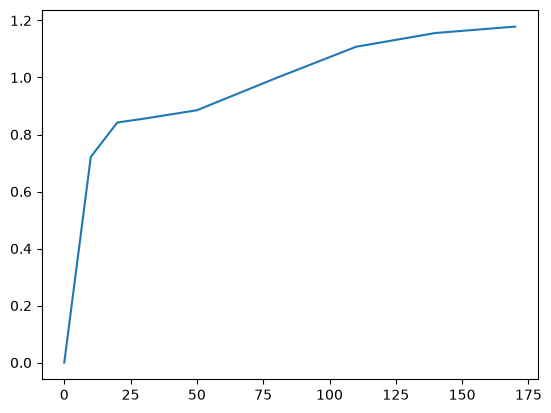

In [8]:
# plot the relation
import matplotlib.pyplot as plt
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values)


In [9]:
## Normalize the value and test the model
## Start picking models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

X, y = kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values
# Do the scaling



In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV


pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('preprocessing', StandardScaler()),
    ('model', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3]
}

loo = LeaveOneOut()
grid_search_model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv = loo,
    scoring = 'neg_mean_squared_error'
)

grid_search_model.fit(X.reshape(-1,1),y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [11]:
grid_search_model.score

<bound method BaseSearchCV.score of GridSearchCV(cv=LeaveOneOut(),
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('preprocessing', StandardScaler()),
                                       ('model', LinearRegression())]),
             param_grid={'poly__degree': [1, 2, 3]},
             scoring='neg_mean_squared_error')>

In [12]:
grid_search_model.cv_results_

{'mean_fit_time': array([0.00133011, 0.00119093, 0.00136362]),
 'std_fit_time': array([2.61046810e-04, 5.07128323e-05, 1.64081072e-04]),
 'mean_score_time': array([0.0005605 , 0.00056815, 0.00058728]),
 'std_score_time': array([4.62269032e-05, 6.98775711e-05, 4.73092232e-05]),
 'param_poly__degree': masked_array(data=[1, 2, 3],
              mask=[False, False, False],
        fill_value=999999),
 'params': [{'poly__degree': 1}, {'poly__degree': 2}, {'poly__degree': 3}],
 'split0_test_score': array([-0.57388356, -0.50074749, -0.51626613]),
 'split1_test_score': array([-0.02424857, -0.08272226, -0.10166957]),
 'split2_test_score': array([-0.05865349, -0.07095882, -0.04039974]),
 'split3_test_score': array([-0.03847373, -0.02281579, -0.00065234]),
 'split4_test_score': array([-0.01416616, -0.00074981, -0.04872641]),
 'split5_test_score': array([-0.00879517, -0.02008814, -0.02400641]),
 'split6_test_score': array([-0.00477448, -0.01355513, -0.00577102]),
 'split7_test_score': array([-0.00

In [13]:
grid_search_model.best_score_, grid_search_model.best_params_

(np.float64(-0.08832981200372592), {'poly__degree': 1})

In [14]:
best_model = grid_search_model.best_estimator_
y_test_predict = best_model.predict(X.reshape(-1,1))
r2_score(y, y_test_predict)

0.5810980802566073

In [15]:
X,y

(array([  0,  10,  20,  30,  50,  80, 110, 140, 170]),
 array([0.     , 0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776,
        1.15607, 1.17853]))

In [16]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


In [17]:
print("X:")
print(X)

print("\ny:")
print(y)

print("\nNaN in X:", np.isnan(X).any())
print("NaN in y:", np.isnan(y).any())

X:
[  0  10  20  30  50  80 110 140 170]

y:
[0.      0.72145 0.84218 0.85548 0.8851  0.99843 1.10776 1.15607 1.17853]

NaN in X: False
NaN in y: False


In [18]:
from sklearn.model_selection import cross_val_predict
reshaped_X = X.reshape(-1,1)
loo_predictions = cross_val_predict(
    best_model,
    reshaped_X,
    y,
    cv = LeaveOneOut()
)

r2_result = r2_score(y,loo_predictions)
print(f"R2 result: {r2_result}")

R2 result: 0.22775725593498108


In [19]:
print(loo_predictions), y

[0.75755103 0.56573048 0.59999518 0.65933279 0.76607832 0.90464741
 1.03866241 1.19734383 1.44361419]


(None,
 array([0.     , 0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776,
        1.15607, 1.17853]))

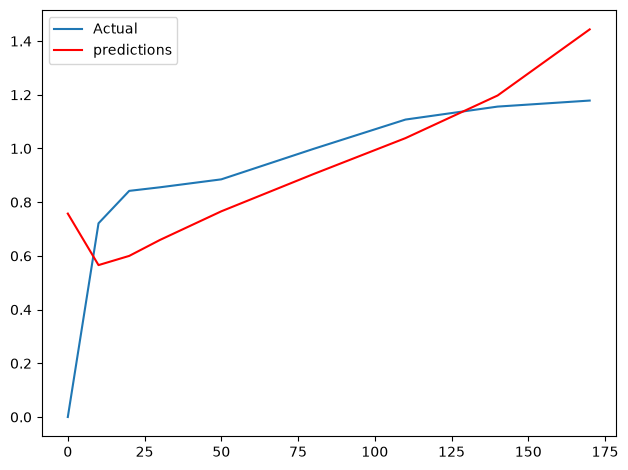

In [20]:
# plot the relation
import matplotlib.pyplot as plt
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values, label = 'Actual')
plt.plot(kinetics_df['Time'].values, loo_predictions, c = 'red', label ='predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
# The data
print(f"Input data: {X}\nOutput Data: {y}")
# Take the model:
# Prepare the data:
X = X.reshape(-1,1)
""""
Polynomial Degree(degree = 2, degree = 3)
RandomForest
GausianProbabilityRegression
"""
model_results_nmse = {
    "Poly_2":[],
    "Poly_3":[],
    "GPR":[],
    "RandomForest":[]
}
#Polynomiad Degree(degree = 2)
print("="*60)
print("Polynomial Model")
print("="*60)
polynomial_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree = 2)),
    ('preprocessing', StandardScaler()),
    ('model', Ridge())
])
print("="*60)
print("Cross Validation using LeaveOneOut")
print("="*60)
scores = cross_val_score(
    polynomial_pipeline,
    X,
    y,
    cv = LeaveOneOut(),
    scoring='neg_mean_squared_error'
).mean()
model_results_nmse['Poly_2'].append(scores.item())
#Polynomiad Degree(degree = 3)
print("="*60)
print("Polynomial Model(degree = 3)")
print("="*60)
polynomial_pipeline_3 = Pipeline([
    ('poly', PolynomialFeatures(degree = 3)),
    ('preprocessing', StandardScaler()),
    ('model', Ridge())
])
print("="*60)
print("Cross Validation using LeaveOneOut")
print("="*60)
scores_3 = cross_val_score(
    polynomial_pipeline_3,
    X,
    y,
    cv = LeaveOneOut(),
    scoring='neg_mean_squared_error').mean()

model_results_nmse['Poly_3'].append(scores_3.item())

# poly_model_degree2 prediction
poly_2_predictions = cross_val_predict(
    polynomial_pipeline,
    X,
    y,
    cv = LeaveOneOut()
)
r2_poly2= r2_score(y, poly_2_predictions)
print(f"Polynomial degree 3 r2 score: {r2_poly2}")

poly_3_predictions = cross_val_predict(
    polynomial_pipeline_3,
    X,
    y,
    cv = LeaveOneOut()
)
r2_poly3= r2_score(y, poly_3_predictions)
print(f"Polynomial degree 3 r2 score: {r2_poly3}")

Input data: [[  0]
 [ 10]
 [ 20]
 [ 30]
 [ 50]
 [ 80]
 [110]
 [140]
 [170]]
Output Data: [0.      0.72145 0.84218 0.85548 0.8851  0.99843 1.10776 1.15607 1.17853]
Polynomial Model
Cross Validation using LeaveOneOut
Polynomial Model(degree = 3)
Cross Validation using LeaveOneOut
Polynomial degree 3 r2 score: 0.2507865760731458
Polynomial degree 3 r2 score: 0.27638478322848525


In [ ]:
model_results_nmse

{'Poly_2': [-0.08569569788091785],
 'Poly_3': [-0.08276775217596838],
 'GPR': [],
 'RandomForest': []}

In [ ]:
#Calculate R2 Value
#you have to make predictions on the dataset, then compare with the test dataset, as in leave one ou

In [ ]:
from typing import List
## Create a function
model_name = {
    'LinearRegression':None,
    'GaussianProbabilityRegression':None,
    'Ridge':None
}
for model_name, value in model_name.items():
    model_name = model_name()

def prediction(model_name:List):
    return None
